##  IMPA Tech - IMPA - Instituto de Matemática Pura e Aplicada

### Participantes: Natália e Heitor

## Análise em Python sobre os casos de VSR e Influenza no Brasil 
  



### Objetivo dessa análise consiste em determinar características epidêmicas para os estados brasieliros em relação ao VSR e Influenza e determinar clusters através dessas características. Bem como analisar brevemente o panorama geral de casos de Covid-19 no Brasil. 

## Bibliotecas necessárias

In [93]:
import pandas as pd
import matplotlib.pyplot as plt


## Carregando a base de dados 

In [94]:

url = "https://github.com/infogripe/Boletim_InfoGripe/raw/refs/heads/main/Dados/InfoGripe/casos_semanais_fx_etaria_virus_sem_filtro_febre.csv"

df = pd.read_csv(url, sep=";")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181482 entries, 0 to 181481
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   SG_UF_NOT              181482 non-null  int64
 1   fx_etaria              181482 non-null  str  
 2   SRAG                   181482 non-null  int64
 3   SARS2                  181482 non-null  int64
 4   VSR                    181482 non-null  int64
 5   FLU                    181482 non-null  int64
 6   FLU_A                  181482 non-null  int64
 7   FLU_AH1N1              181482 non-null  int64
 8   FLU_AH3N2              181482 non-null  int64
 9   FLU_ANSUBTPD           181482 non-null  int64
 10  FLU_ANSUBTPV           181482 non-null  int64
 11  FLU_AINC               181482 non-null  int64
 12  FLU_AOUT               181482 non-null  int64
 13  FLU_B                  181482 non-null  int64
 14  FLU_BVIC               181482 non-null  int64
 15  FLU_BYAM               18148

C:\Users\Lya\AppData\Local\Temp\ipykernel_17952\741302333.py:3: DtypeWarning: Columns (0: DS_UF_SIGLA) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, sep=";")


In [95]:
df.head()

,SG_UF_NOT,fx_etaria,SRAG,SARS2,VSR,FLU,FLU_A,FLU_AH1N1,FLU_AH3N2,FLU_ANSUBTPD,...,PARA4,OUTROS,positivos,negativos,aguardando,DS_UF_SIGLA,epiyear,epiweek,Semana epidemiológica,Ano epidemiológico
0,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,16,16,2009
1,0,< 2,3,0,0,1,1,0,0,0,...,0,1,2,0,0,BR,2009,17,17,2009
2,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,18,18,2009
3,0,< 2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,BR,2009,19,19,2009
4,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,20,20,2009


## Analisando os casos de vsr (ignorando a faixa etária) de 2009 - 2026 

In [96]:
vsr = (
    df.groupby(
        ["DS_UF_SIGLA", "epiyear", "epiweek"]
    )["VSR"]
    .sum()
    .reset_index()
)

vsr.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR
0,AC,2009,16,0
1,AC,2009,17,0
2,AC,2009,18,0
3,AC,2009,19,0
4,AC,2009,20,0


## Limpeza dos dados 

In [97]:
vsr.info()

<class 'pandas.DataFrame'>
RangeIndex: 25032 entries, 0 to 25031
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   DS_UF_SIGLA  25032 non-null  str  
 1   epiyear      25032 non-null  int64
 2   epiweek      25032 non-null  int64
 3   VSR          25032 non-null  int64
dtypes: int64(3), str(1)
memory usage: 834.3 KB


In [98]:
# checando se há valores duplicados
vsr.duplicated().sum()

np.int64(0)

In [125]:
# checando se não há estados estranhos 
sorted(vsr["DS_UF_SIGLA"].unique())

['AC',
 'AL',
 'AM',
 'AP',
 'BA',
 'BR',
 'CE',
 'DF',
 'ES',
 'GO',
 'MA',
 'MG',
 'MS',
 'MT',
 'PA',
 'PB',
 'PE',
 'PI',
 'PR',
 'RJ',
 'RN',
 'RO',
 'RR',
 'RS',
 'SC',
 'SE',
 'SP',
 'TO']

In [126]:
# checando se as semanas epidemiológicas são válidas
vsr["epiweek"].describe()

count    25032.000000
mean        26.530201
std         15.018882
min          1.000000
25%         14.000000
50%         26.000000
75%         40.000000
max         53.000000
Name: epiweek, dtype: float64

In [127]:
# checando se há casos negativos 
(vsr["VSR"] < 0).sum()

np.int64(0)

Antes da análise, a base foi inspecionada para verificar possíveis problemas nos dados. Não foram encontrados valores nulos ou inconsistências nas variáveis utilizadas.

### Visualizando os dados de 2009 e 2010

In [99]:
vsr[vsr["epiyear"] == 2009]

,DS_UF_SIGLA,epiyear,epiweek,VSR
0,AC,2009,16,0
1,AC,2009,17,0
2,AC,2009,18,0
3,AC,2009,19,0
4,AC,2009,20,0
...,...,...,...,...
24170,TO,2009,48,0
24171,TO,2009,49,0
24172,TO,2009,50,0
24173,TO,2009,51,0


In [100]:
vsr[vsr["epiyear"] == 2010]

,DS_UF_SIGLA,epiyear,epiweek,VSR
37,AC,2010,1,0
38,AC,2010,2,0
39,AC,2010,3,0
40,AC,2010,4,0
41,AC,2010,5,0
...,...,...,...,...
24222,TO,2010,48,0
24223,TO,2010,49,0
24224,TO,2010,50,0
24225,TO,2010,51,0


Note que a cada ano tem a semana 1, 2, ..., para facilitar nossa análise, adicionaremos uma nova coluna de forma que o número da semana seja crescente.

In [101]:
# ignorando os estados por enquanto
vsr_global = (
    vsr.groupby(["epiyear", "epiweek"])["VSR"]
       .sum()
       .reset_index()
)

vsr_global.head()

,epiyear,epiweek,VSR
0,2009,16,0
1,2009,17,0
2,2009,18,0
3,2009,19,0
4,2009,20,0


In [128]:
# adicioanndo nova coluna 
vsr_global["semana_global"] = range(1, len(vsr_global) + 1)

vsr_global

,epiyear,epiweek,VSR,semana_global
0,2009,16,0,1
1,2009,17,0,2
2,2009,18,0,3
3,2009,19,0,4
4,2009,20,0,5
...,...,...,...,...
889,2026,18,5508,890
890,2026,19,6220,891
891,2026,20,5248,892
892,2026,21,2860,893


### Panorama geral de casos de VSR no Brasil no período de 2009 a 2026

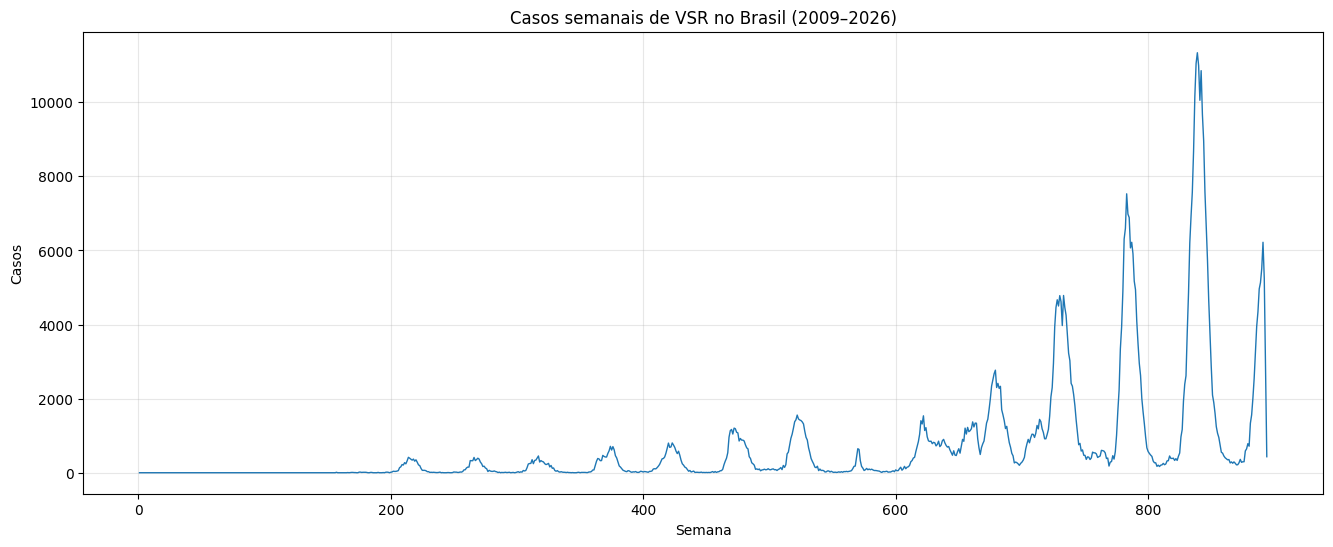

In [103]:
plt.figure(figsize=(16,6))

plt.plot(
    vsr_global["semana_global"],
    vsr_global["VSR"],
    linewidth=1
)

plt.title("Casos semanais de VSR no Brasil (2009–2026)")
plt.xlabel("Semana")
plt.ylabel("Casos")
plt.grid(alpha=0.3)

plt.show()

fazer um cmentário depois sobre isso 

## Análise de VSR de 2019 - 2025

In [104]:
# Como o foco da nossa análise é referente aos anos de 2019 a 2025, é necessário fazer uma filtragem 
vsr_2019_2025 = vsr[
    (vsr["epiyear"] >= 2019) &
    (vsr["epiyear"] <= 2025)
].copy()

vsr_2019_2025.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR
506,AC,2019,1,6
507,AC,2019,2,6
508,AC,2019,3,2
509,AC,2019,4,0
510,AC,2019,5,0
